In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Define model architecture.

In [12]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(4608, 64)
        self.fc2 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.cn1(x)
        x = F.relu(x)
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dp1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp2(x)
        x = self.fc2(x)
        op = F.log_softmax(x, dim=1)
        return op

## define training and inference routines

In [16]:
def train(model, device, train_dataloader, optim, epoch):
    model.train()
    for b_i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        optim.zero_grad()
        pred_prob = model(X)
        loss = F.nll_loss(pred_prob, y)
        loss.backward()
        optim.step()
        if b_i % 10 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.6f}'.format(
                epoch, b_i * len(X), len(train_dataloader.dataset),
                100. * b_i / len(train_dataloader), loss.item()))

In [17]:
def test(model, device, test_dataloader):
    model.eval()
    loss = 0
    success = 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred_prob = model(X)
            loss += F.nll_loss(pred_prob, y, reduction='sum').item()
            pred = pred_prob.argmax(dim=1, keepdim = True)
            success += pred.eq(y.view_as(pred)).sum().item()
    loss /= len(test_dataloader.dataset)
    
    print('\nTest dataset: Overall Loss: {:.4f}, Overall Accuracy: {}/{} ({:.0f}%)\n'.format(
        loss, success, len(test_dataloader.dataset),
        100. * success / len(test_dataloader.dataset)))

## Create data loaders

In [19]:
train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(
        '../data',
        train=True,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1302,), (0.3069))
        ])
    ),
    batch_size=32, shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(
        '../data',
        train=False,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1302,), (0.3069,))
        ])        
    ),
    batch_size=500, shuffle=False
)

## define optimizers

In [30]:
torch.manual_seed(0)
device = torch.device('cpu')

model = ConvNet()
optimizer = optim.Adadelta(model.parameters(), lr=0.5)

## Model Training

In [31]:
for epoch in range(1, 3):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

/opt/anaconda3/envs/mastering-pytorch/lib/python3.10/site-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


epoch: 1 [0/60000 (0%)]	 training loss: 2.291804
epoch: 1 [320/60000 (1%)]	 training loss: 1.583885
epoch: 1 [640/60000 (1%)]	 training loss: 1.175324
epoch: 1 [960/60000 (2%)]	 training loss: 0.909112
epoch: 1 [1280/60000 (2%)]	 training loss: 1.041991
epoch: 1 [1600/60000 (3%)]	 training loss: 0.522899
epoch: 1 [1920/60000 (3%)]	 training loss: 0.457852
epoch: 1 [2240/60000 (4%)]	 training loss: 0.230259
epoch: 1 [2560/60000 (4%)]	 training loss: 0.164381
epoch: 1 [2880/60000 (5%)]	 training loss: 0.415874
epoch: 1 [3200/60000 (5%)]	 training loss: 0.457875
epoch: 1 [3520/60000 (6%)]	 training loss: 0.840372
epoch: 1 [3840/60000 (6%)]	 training loss: 0.095234
epoch: 1 [4160/60000 (7%)]	 training loss: 0.356803
epoch: 1 [4480/60000 (7%)]	 training loss: 0.529303
epoch: 1 [4800/60000 (8%)]	 training loss: 0.241805
epoch: 1 [5120/60000 (9%)]	 training loss: 0.450885
epoch: 1 [5440/60000 (9%)]	 training loss: 0.065128
epoch: 1 [5760/60000 (10%)]	 training loss: 0.128393
epoch: 1 [6080/60

## Run inference

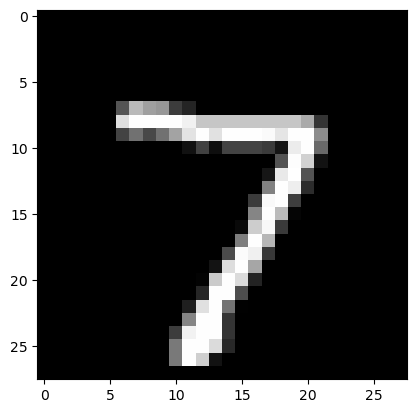

In [32]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)
plt.imshow(sample_data[0][0], cmap='gray', interpolation='none')
plt.show()

In [33]:
print(f"Model prediction is: {model(sample_data).data.max(1)[1][0]}")
print(f"Ground truth is: {sample_targets[0]}")

Model prediction is: 7
Ground truth is: 7
